# Онтологии

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Курс лекций [Semantic Technologies for Developers](https://yadi.sk/d/SepS4JBLhDYy4Q), лекция №03
* https://cambridgesemantics.com/blog/semantic-university/learn-owl-rdfs/
* https://cambridgesemantics.com/blog/semantic-university/learn-owl-rdfs/owl-references-humans/
* https://www.w3.org/2007/OWL/refcardLetter
* https://dspace.kpfu.ru/xmlui/bitstream/handle/net/159234/20200802_2.pdf?sequence=-1
* https://en.wikibooks.org/wiki/SPARQL/Aggregate_functions
* https://joinup.ec.europa.eu/sites/default/files/document/2014-02/D3.1.7%20Training%20Module%201.3%20Introduction%20to%20RDF_SPARQL_EUI_v0.08.pptx
* https://www.jarrar.info/courses/KnowledgeEngineering/Jarrar.LectureNotes.RDFS.pdf
* https://www.jarrar.info/courses/KnowledgeEngineering/Jarrar.LectureNotes.OWL.pdf
* https://migalkin.github.io/kgcourse2021/lectures/lecture2
* https://protege.stanford.edu/

## Вопросы для совместного обсуждения

1\. Обсудите стандарты RDFS и OWL, их синтаксис и возможности, примеры использования.

```turtle
@prefix : <http://example.org/> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
```

```turtle
@prefix : <http://example.org/> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix owl: <http://www.w3.org/2002/07/owl#> .
```

## Задачи для самостоятельного решения

<p class="task" id="1"></p>


1\. Опишите онтологию предметной области "Университ", используя язык RDFS. 

Она должна включать:

    - описание класса `University` с подходящим названием на русском языке;
    - описание класса `City` с подходящим названием на русском языке;
    - описание класса `Person` с подходящим названием на русском языке;
    - описание отношения `name` для описания названия университета;
    - описание отношения `established` для описания даты основания университета;
    - описание отношения `rector` для указания ректора университа;
    - описание отношения `dateOfBirth` для указания даты рождения человека;
    - описание отношения `fullName` для указания ФИО человека.
   
Сериализуйте онтологию в формате turtle и вставьте в виде текстовой ячейки.

- [ ] Проверено на семинаре

In [1]:
from rdflib import Graph

rdfs_ontology_data = """
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix uni: <http://example.org/university#> .

uni:University a rdfs:Class ;
    rdfs:label "Университет"@ru .

uni:City a rdfs:Class ;
    rdfs:label "Город"@ru .

uni:Person a rdfs:Class ;
    rdfs:label "Человек"@ru .

uni:name a rdf:Property ;
    rdfs:label "название"@ru ;
    rdfs:domain uni:University ;
    rdfs:range rdfs:Literal .

uni:established a rdf:Property ;
    rdfs:label "дата основания"@ru ;
    rdfs:domain uni:University ;
    rdfs:range rdfs:Literal .

uni:rector a rdf:Property ;
    rdfs:label "ректор"@ru ;
    rdfs:domain uni:University ;
    rdfs:range uni:Person .

uni:dateOfBirth a rdf:Property ;
    rdfs:label "дата рождения"@ru ;
    rdfs:domain uni:Person ;
    rdfs:range rdfs:Literal .

uni:fullName a rdf:Property ;
    rdfs:label "ФИО"@ru ;
    rdfs:domain uni:Person ;
    rdfs:range rdfs:Literal .
"""

g = Graph()
g.parse(data=rdfs_ontology_data, format="turtle")


<Graph identifier=N938c1c6e5366447ea4b58bfe733fafea (<class 'rdflib.graph.Graph'>)>

<p class="task" id="2"></p>


2\. Напишите SPARQL-запрос, который выводит на экран набор классов (идентификатор и название на русском), используемых в данной предметной области. 

- [ ] Проверено на семинаре

In [2]:
sparql_query_classes = """
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?class ?label
WHERE {
  ?class a rdfs:Class .
  ?class rdfs:label ?label .
  FILTER(LANG(?label) = "ru")
}
"""

In [ ]:
results = g.query(sparql_query_classes)

In [ ]:
print("Результат выполнения SPARQL-запроса:")
print("-" * 40)
for row in results:
  print(f"Идентификатор: {row['class']}, Название: {row['label']}")
print("-" * 40)

Результат выполнения SPARQL-запроса:
----------------------------------------
Идентификатор: http://example.org/university#University, Название: Университет
Идентификатор: http://example.org/university#City, Название: Город
Идентификатор: http://example.org/university#Person, Название: Человек
----------------------------------------


<p class="task" id="3"></p>


3\. Напишите SPARQL-запрос, который выводит на экран набор отношений (идентификатор, домен и множество допустимых значений), используемых в данной предметной области. 

- [ ] Проверено на семинаре

In [5]:
sparql_query_properties = """
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?property ?domain ?range
WHERE {
  ?property a rdf:Property .
  OPTIONAL { ?property rdfs:domain ?domain . }
  OPTIONAL { ?property rdfs:range ?range . }
}
"""

In [6]:
print("Результат выполнения SPARQL-запроса:")
print("-" * 40)
for row in g.query(sparql_query_properties):
    print(f"Идентификатор: {row['property']}\n  Домен: {row['domain']}\n  Диапазон: {row['range']}\n")
print("-" * 40)    

Результат выполнения SPARQL-запроса:
----------------------------------------
Идентификатор: http://example.org/university#name
  Домен: http://example.org/university#University
  Диапазон: http://www.w3.org/2000/01/rdf-schema#Literal

Идентификатор: http://example.org/university#established
  Домен: http://example.org/university#University
  Диапазон: http://www.w3.org/2000/01/rdf-schema#Literal

Идентификатор: http://example.org/university#rector
  Домен: http://example.org/university#University
  Диапазон: http://example.org/university#Person

Идентификатор: http://example.org/university#dateOfBirth
  Домен: http://example.org/university#Person
  Диапазон: http://www.w3.org/2000/01/rdf-schema#Literal

Идентификатор: http://example.org/university#fullName
  Домен: http://example.org/university#Person
  Диапазон: http://www.w3.org/2000/01/rdf-schema#Literal

----------------------------------------


<p class="task" id="4"></p>


4\. Опишите онтологию той же предметной области, используя язык OWL2. 

Дополнительно укажите, что отношения "университет располагается в городе" и "дата рождения человека" являются функциональным. Для отношения "дата рождения человека" укажите ограничение на минимальное и максимальное значение (01.01.1900 и 01.01.2000 соответственно). 

Для создания онтологии используйте инструмент Protégé (предпочтительно десктопную версию). После завершения формирования онтологии сделайте скриншоты иерархии классов, object properties и data properties и вставьте в ноутбук.

Сериализуйте онтологию в формате turtle и вставьте в виде текстовой ячейки.

- [ ] Проверено на семинаре

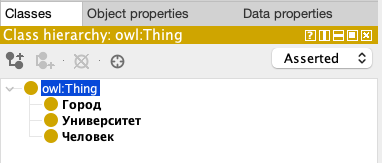

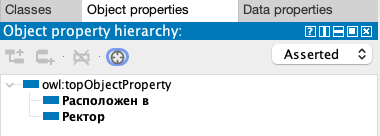

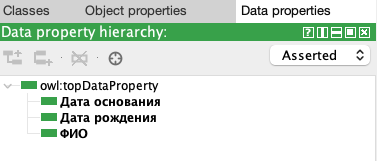

@prefix : <http://example.org/university-owl#> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix owl: <http://www.w3.org/2002/07/owl#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

:University a owl:Class ;
    rdfs:label "Университет"@ru .

:City a owl:Class ;
    rdfs:label "Город"@ru .

:Person a owl:Class ;
    rdfs:label "Человек"@ru .

:locatedIn a owl:ObjectProperty , owl:FunctionalProperty ;
    rdfs:label "Расположен в"@ru ;
    rdfs:domain :University ;
    rdfs:range :City .

:rector a owl:ObjectProperty ;
    rdfs:label "Ректор"@ru ;
    rdfs:domain :University ;
    rdfs:range :Person .

:fullName a owl:DatatypeProperty ;
    rdfs:label "ФИО"@ru ;
    rdfs:domain :Person ;
    rdfs:range xsd:string .

:established a owl:DatatypeProperty ;
    rdfs:label "Дата основания"@ru ;
    rdfs:domain :University ;
    rdfs:range xsd:date .

:dateOfBirth a owl:DatatypeProperty , owl:FunctionalProperty ;
    rdfs:label "Дата рождения"@ru ;
    rdfs:domain :Person ;
    rdfs:range [
        a rdfs:Datatype ;
        owl:onDatatype xsd:date ;
        owl:withRestrictions (
            [ xsd:minInclusive "1900-01-01"^^xsd:date ]
            [ xsd:maxInclusive "2000-01-01"^^xsd:date ]
        )
    ] .

<p class="task" id="5"></p>


5\. В файлах `data1.ttl` и `data2.ttl` находится информация о различных языках программирования. Эти данные получены из различных источников, имеющих различные схемы для хранения данных. Разработайте онтологию в формате OWL2 для объединения этих двух источников данных. Для этого опишите класс "Язык программирования" и набор атрибутов. Данную онтологию сохраните в отдельный файл `ontology.owl`. 

Чтобы связать онтологию и имеющиеся данные, создайте файл `extra.ttl`, в котором укажите, какие свойства являются эквивалентными. Там же укажите, какие субъекты (конкретные языки программирования) являются эквивалентными. 

Вставьте содержимое двух созданных файлов в виде текстовых ячеек.

- [ ] Проверено на семинаре

In [ ]:
# Содержимое для файла ontology.owl
ontology_owl_content = """
# --- Префиксы ---
@prefix onto: <http://unifiedschema.org/schema#> .
@prefix owl: <http://www.w3.org/2002/07/owl#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .

# --- Определение онтологии ---
<http://unifiedschema.org/schema> a owl:Ontology .

# --- Класс ---
onto:ProgrammingLanguage a owl:Class ;
    rdfs:label "Programming Language"@en .

# --- Свойства (Атрибуты) ---
onto:name a owl:DatatypeProperty ;
    rdfs:label "name"@en .

onto:creator a owl:DatatypeProperty ;
    rdfs:label "creator"@en .

onto:releaseYear a owl:DatatypeProperty ;
    rdfs:label "release year"@en .

onto:latestVersion a owl:DatatypeProperty ;
    rdfs:label "latest version"@en .

onto:paradigm a owl:DatatypeProperty ;
    rdfs:label "paradigm"@en .

onto:isPopular a owl:DatatypeProperty ;
    rdfs:label "is popular"@en .
"""


In [ ]:
# Содержимое для файла extra.ttl 
# Точно так же определяем содержимое второго файла.
extra_ttl_content = """
# --- Префиксы ---
@prefix onto: <http://unifiedschema.org/schema#> .
@prefix owl: <http://www.w3.org/2002/07/owl#> .
@prefix res1: <http://resource1.org/schema#> .
@prefix res2: <http://resource2.org/schema#> .

# --- Эквивалентность классов ---
res1:programmingLanguage owl:equivalentClass onto:ProgrammingLanguage .
res2:language owl:equivalentClass onto:ProgrammingLanguage .

# --- Эквивалентность свойств ---
res1:name owl:equivalentProperty onto:name .
res1:creator owl:equivalentProperty onto:creator .
res1:releaseYear owl:equivalentProperty onto:releaseYear .
res1:latestVersion owl:equivalentProperty onto:latestVersion .

res2:langName owl:equivalentProperty onto:name .
res2:inventor owl:equivalentProperty onto:creator .
res2:yearReleased owl:equivalentProperty onto:releaseYear .
res2:currentVersion owl:equivalentProperty onto:latestVersion .
res2:paradigmUsed owl:equivalentProperty onto:paradigm .
res2:isPopular owl:equivalentProperty onto:isPopular .

# --- Эквивалентность экземпляров ---
res1:Python owl:sameAs res2:PythonLang .
res1:JavaScript owl:sameAs res2:JS .
res1:Ruby owl:sameAs res2:RubyLang .
"""

In [ ]:
# --- Процесс создания файлов ---
with open('ontology.owl', 'w', encoding='utf-8') as f:
    f.write(ontology_owl_content)

with open('extra.ttl', 'w', encoding='utf-8') as f:
    f.write(extra_ttl_content)

<p class="task" id="6"></p>


6\. При помощи `rdflib` создайте граф на основе четырех имеющихся файлов. Напишите запрос на SPARQL, который для каждого отношения из онтологии позволит узнать, сколько и каких существует эквивалентных свойств в файлах с данными. 

- [ ] Проверено на семинаре

In [9]:
import pandas as pd

In [10]:
g = Graph()
g.parse(source='data1.ttl', format="turtle")
g.parse(source='data2.ttl', format="turtle")
g.parse(source='ontology.owl', format="turtle")
g.parse(source='extra.ttl', format="turtle")

# Запрос
query6 = """
    PREFIX onto: <http://unifiedschema.org/schema#>
    PREFIX owl: <http://www.w3.org/2002/07/owl#>

    SELECT ?onto_prop (COUNT(?source_prop) AS ?count) (GROUP_CONCAT(?source_prop; separator=", ") AS ?equivalent_properties)
    WHERE {
        ?onto_prop a owl:DatatypeProperty .
        FILTER(STRSTARTS(STR(?onto_prop), STR(onto:)))

        ?source_prop owl:equivalentProperty ?onto_prop .
    }
    GROUP BY ?onto_prop
"""

results = []
for row in g.query(query6):
    results.append({
        "Свойство онтологии": row.onto_prop,
        "Кол-во эквивалентов": row['count'],
        "Эквивалентные свойства": row.equivalent_properties
    })
pd.DataFrame(results)

,Свойство онтологии,Кол-во эквивалентов,Эквивалентные свойства
0,http://unifiedschema.org/schema#name,2,"http://resource2.org/schema#langName, http://r..."
1,http://unifiedschema.org/schema#creator,2,"http://resource2.org/schema#inventor, http://r..."
2,http://unifiedschema.org/schema#releaseYear,2,"http://resource2.org/schema#yearReleased, http..."
3,http://unifiedschema.org/schema#latestVersion,2,"http://resource2.org/schema#currentVersion, ht..."
4,http://unifiedschema.org/schema#paradigm,1,http://resource2.org/schema#paradigmUsed
5,http://unifiedschema.org/schema#isPopular,1,http://resource2.org/schema#isPopular


<p class="task" id="7"></p>


7\. Напишите запрос, который выводит всю информацию о языках программирования из файла `data1.ttl`, расширенную за счет недостающей информации из `data2.ttl`. Для связки двух файлов используйте новые тройки из файла `extra.ttl`.

- [ ] Проверено на семинаре

In [11]:
query7 = """
    PREFIX res1: <http://resource1.org/schema#>
    PREFIX res2: <http://resource2.org/schema#>
    PREFIX owl: <http://www.w3.org/2002/07/owl#>

    SELECT ?lang_name ?creator ?release_year ?paradigm
    WHERE {
        ?lang1 a res1:programmingLanguage .
        ?lang1 res1:name ?lang_name .
        ?lang1 res1:creator ?creator .
        ?lang1 res1:releaseYear ?release_year .

        OPTIONAL {
            ?lang1 owl:sameAs ?lang2 .
            ?lang2 res2:paradigmUsed ?paradigm .
        }
    }
    ORDER BY ?lang_name
"""
results = []
for row in g.query(query7):
    results.append({
        "Название": row.lang_name,
        "Создатель": row.creator,
        "Год": row.release_year,
        "Парадигма": row.paradigm or "N/A"
    })
pd.DataFrame(results)

,Название,Создатель,Год,Парадигма
0,C#,Microsoft,2000,N/A
1,Java,James Gosling,1995,N/A
2,JavaScript,Brendan Eich,1995,"Event-Driven, Functional"
3,Python,Guido van Rossum,1991,"Object-Oriented, Procedural"
4,Ruby,Yukihiro Matsumoto,1995,"Object-Oriented, Functional"


<p class="task" id="8"></p>


8\. Напишите запрос, который возвращает создателей всех языков программирования, используя для поиска только отношение из онтологии (в запросе явно можно указать только его, нельзя указать отношения с префиксами res1, res2). 

- [ ] Проверено на семинаре

In [12]:
pip install owlrl

Note: you may need to restart the kernel to use updated packages.


In [13]:
from owlrl import DeductiveClosure, OWLRL_Semantics

DeductiveClosure(OWLRL_Semantics).expand(g)

query8 = """
    PREFIX onto: <http://unifiedschema.org/schema#>
    PREFIX owl: <http://www.w3.org/2002/07/owl#>

    SELECT DISTINCT ?lang_name ?creator
    WHERE {
        ?lang onto:name ?lang_name .
        ?lang onto:creator ?creator .
    }
    ORDER BY ?lang_name
"""

results = []
for row in g.query(query8):
    results.append({"Язык": row.lang_name, "Создатель": row.creator})


pd.DataFrame(results)

,Язык,Создатель
0,C#,Microsoft
1,Java,James Gosling
2,JavaScript,Brendan Eich
3,Kotlin,JetBrains
4,Python,Guido van Rossum
5,Ruby,Yukihiro Matsumoto
